# Credit Risk Prediction : ML-Powered 
## 📌 Project Overview
This project aims to predict whether a customer is likely to default on a loan using machine learning techniques. The goal is to assist financial institutions in making data-driven lending decisions and minimizing financial risk.

## 🎯 Problem Statement

In the financial industry, loan defaults can lead to significant losses. Traditional credit evaluation methods are often time-consuming and may lack consistency.

The objective of this project is to build a machine learning model that can classify customers as **high-risk** or **low-risk** based on their financial and demographic data.

##  Data Handling

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("credit_risk_raw_data.csv")

In [5]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [6]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [7]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [8]:
df.shape

(1000, 11)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [10]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.dropna().reset_index(drop=True)

In [13]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [14]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [15]:
df.drop(columns= 'Unnamed: 0', inplace= True)

In [16]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


## Exploratory Data Analysis (EDA)
### Data Visualization

### 📌 Distribution Insights

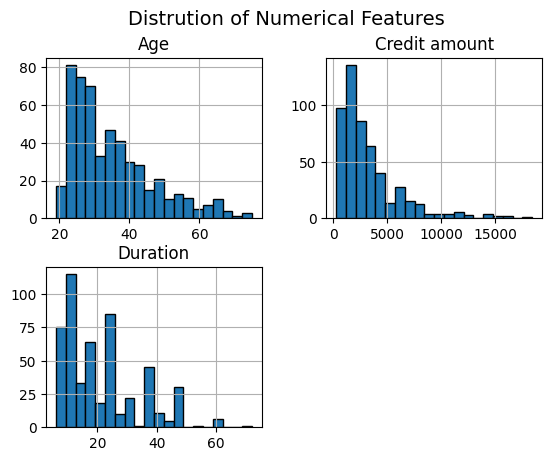

In [17]:
df[['Age','Credit amount', 'Duration']].hist(bins=20, edgecolor = "black")
plt.suptitle("Distrution of Numerical Features", fontsize = 14)
plt.show()

- **Age**: Majority of customers fall between 25–40 years → dataset dominated by young to middle-aged individuals  
- **Credit Amount**: Right-skewed distribution → most loans are small, with few high-value outliers  
- **Duration**: Most loans are short-term (12–30 months)  

✅ **Insight:**  
Most customers take smaller loans for shorter durations.

### 📦 Outlier Analysis (Boxplots)


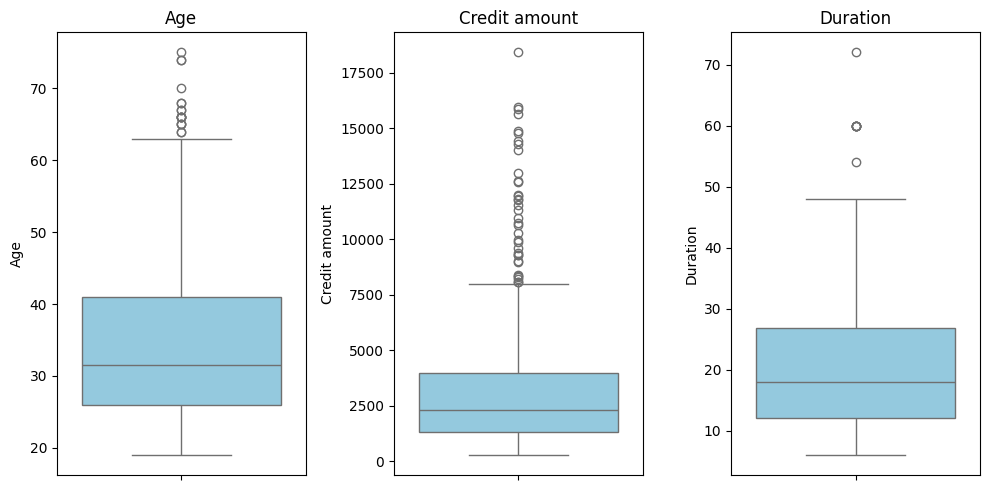

In [18]:
plt.figure(figsize=(10, 5))

for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

- **Credit Amount** shows significant outliers → presence of high-value loans  
- **Duration** has some long-term outliers  
- **Age** is relatively stable with fewer extreme values  

✅ **Insight:**  
Loan amount and duration vary widely and may strongly influence credit risk.

In [19]:
df.query("Duration >=60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


## 🧾 Categorical Features Analysis


In [20]:
categorical_cols = [
    "Sex",
    "Job",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Purpose"
]

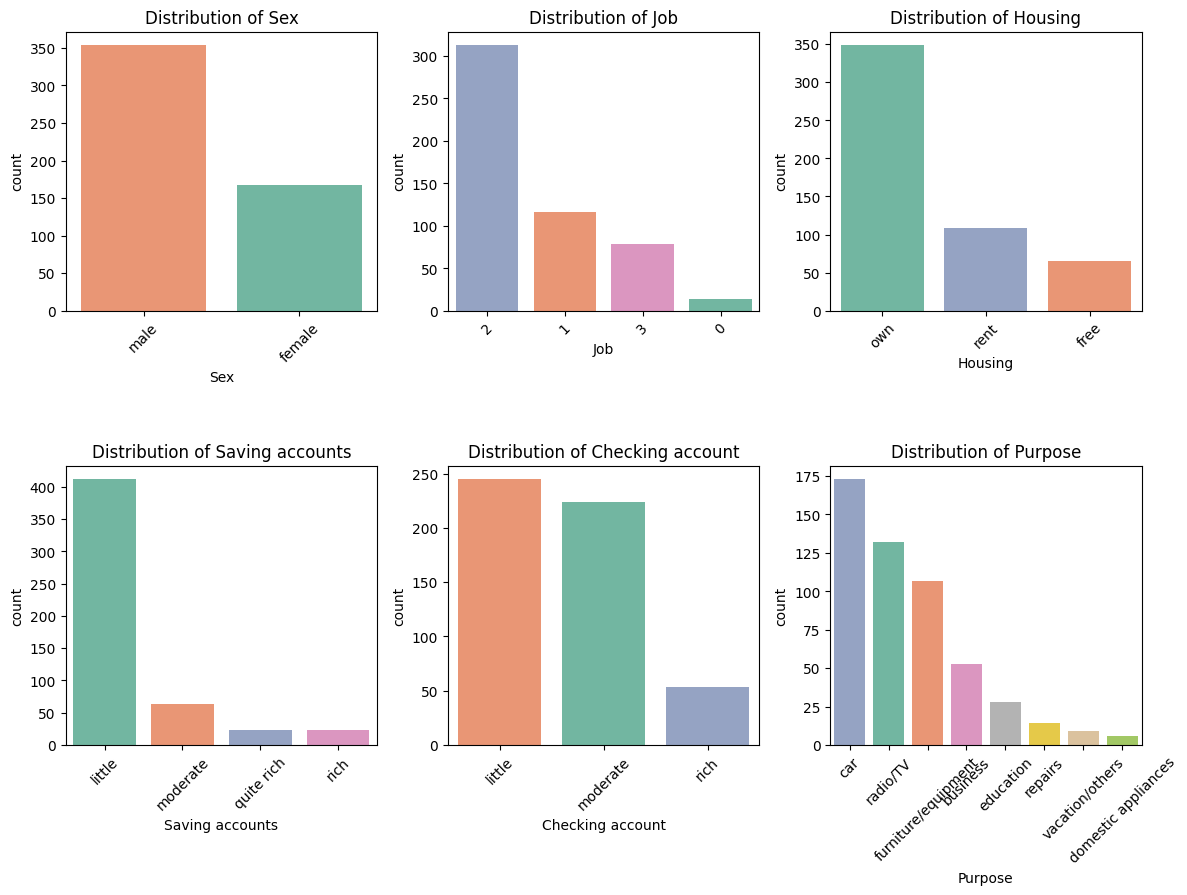

In [56]:
n = len(categorical_cols)
rows = (n // 3) + 1

plt.figure(figsize=(12, 4 * rows))

for i, col in enumerate(categorical_cols):
    plt.subplot(rows, 3, i+1)
    
    sns.countplot(
        data=df,
        x=col,
        hue=col,              # ✅ fix
        palette="Set2",
        order=df[col].value_counts().index,
        legend=False          # ✅ avoid duplicate legend
    )
    
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 👤 Customer Profile
- **Sex**: Majority are male customers  
- **Job**: Most belong to mid-level job category (Job = 2)  
- **Housing**: Most customers own houses  

### 💰 Financial Status
- **Saving Accounts**: Majority have low savings ("little")  
- **Checking Account**: Most have little to moderate balance  

### 🎯 Loan Purpose
- Most common purposes:
  - Car  
  - Radio/TV  
  - Furniture/Equipment  

✅ **Insight:**  
Dataset represents average-income individuals with relatively low savings

## 🔥 Correlation Analysis

In [22]:
corr = df[['Age', 'Job' , 'Credit amount', 'Duration']].corr()

In [23]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


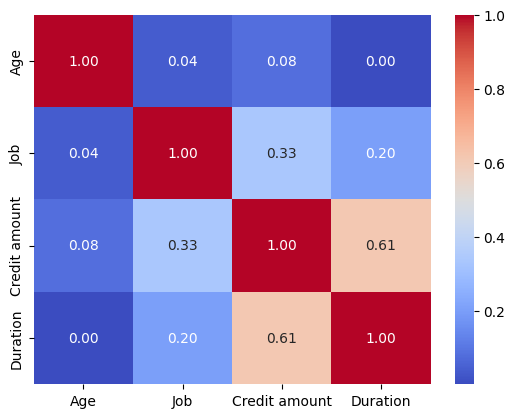

In [24]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

- Strong positive correlation between:
  - **Credit Amount & Duration (~0.6)**  
- Weak correlation:
  - Age with other variables  

✅ **Insight:**  
Larger loans are generally associated with longer repayment durations.

In [25]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [26]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [27]:
pd.pivot_table(df, values= "Credit amount" , index= "Housing" , columns= "Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


## 📉 Relationship Analysis


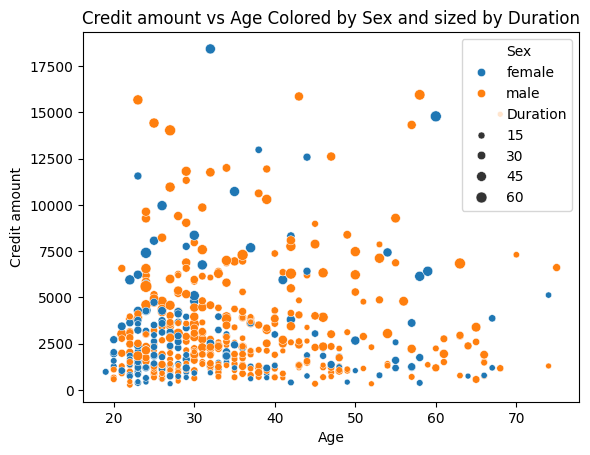

In [28]:
sns.scatterplot (data= df , x = "Age" , y = "Credit amount" , hue= "Sex" , size= "Duration")
plt.title("Credit amount vs Age Colored by Sex and sized by Duration")
plt.show()

### 📍 Age vs Credit Amount (Scatter Plot)
- No strong relationship between age and loan amount  
- Loan values spread across all age groups  
- Larger loans linked with longer durations  

✅ **Insight:**  
Age is not a strong predictor of credit behavior.

### 💳 Credit Amount vs Saving Accounts (Violin Plot)


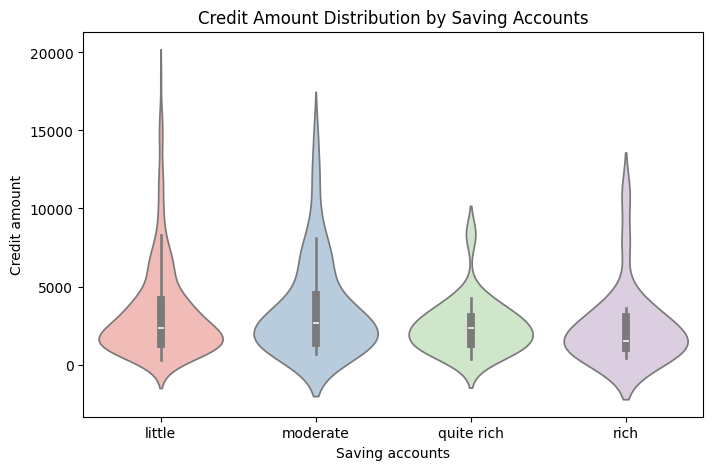

In [57]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="Saving accounts",
    y="Credit amount",
    hue="Saving accounts", 
    palette="Pastel1",
    legend=False             
)

plt.title("Credit Amount Distribution by Saving Accounts")
plt.show()

- Customers with low savings show wider variation in loan amounts  
- Higher savings customers have more controlled borrowing  

✅ **Insight:**  
Lower savings indicate less predictable financial behavior.

In [30]:
df["Risk"].value_counts(normalize= True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

## ⚠️ Risk-Based Feature Analysis


In [31]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

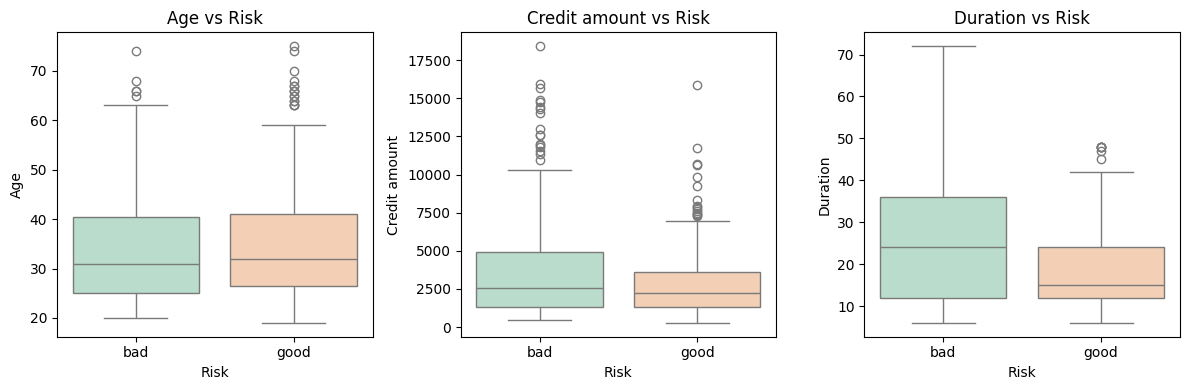

In [58]:
plt.figure(figsize=(12, 4))

for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i+1)
    
    sns.boxplot(
        data=df,
        x="Risk",
        y=col,
        hue="Risk",          # ✅ fix
        palette="Pastel2",
        legend=False         # ✅ remove duplicate legend
    )
    
    plt.title(f"{col} vs Risk")

plt.tight_layout()
plt.show()

### 📊 Age vs Risk
- Minimal difference between good and bad risk  

### 💰 Credit Amount vs Risk
- Higher loan amounts → higher probability of default  

### ⏳ Duration vs Risk
- Longer loan duration → increased default risk  

✅ **Insight:**  
Loan size and duration are key drivers of credit risk.

## 👥 Categorical Features vs Risk

In [33]:
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


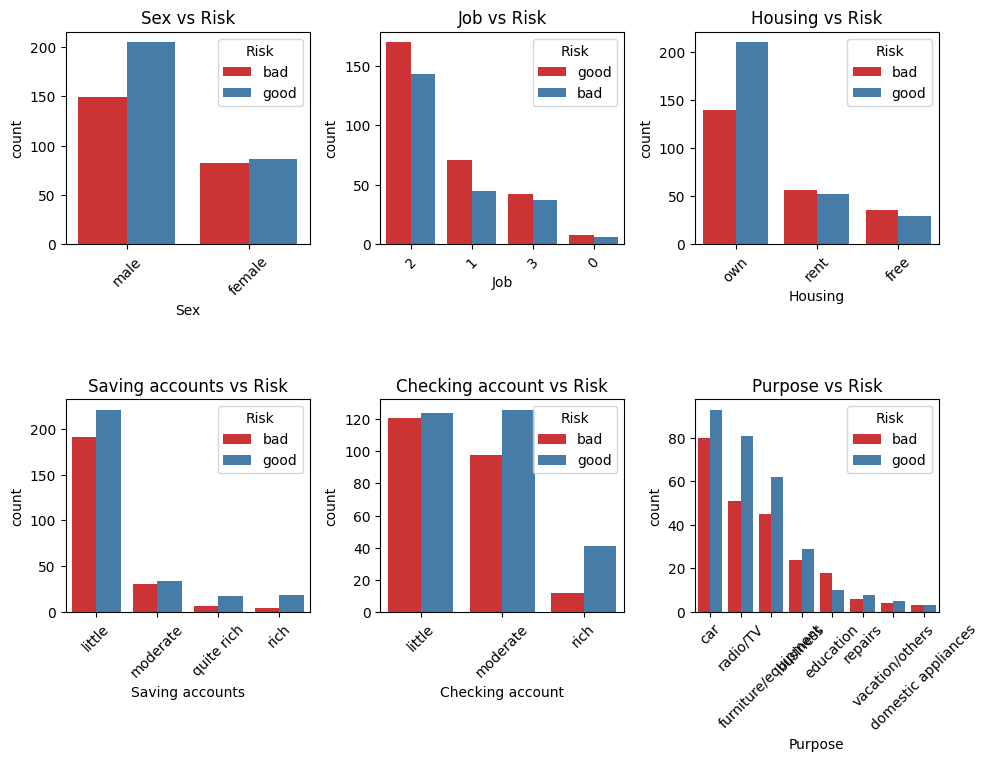

In [34]:
plt.figure(figsize=(10, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(
        data=df,
        x=col,
        hue="Risk",
        palette="Set1",
        order=df[col].value_counts().index
    )
    plt.title(f"{col} vs Risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 🚻 Sex vs Risk
- No significant difference between male and female  

✅ **Insight:**  
Gender is not a strong predictor of risk.

---

### 💼 Job vs Risk
- Lower job category → higher bad risk  
- Stable jobs → more good risk  

✅ **Insight:**  
Employment stability impacts creditworthiness.

---

### 🏠 Housing vs Risk
- Homeowners → more good risk  
- Rent/free → slightly higher bad risk  

✅ **Insight:**  
Asset ownership reduces default risk.

---

### 💰 Saving Accounts vs Risk
- Low savings → higher bad risk  
- High savings → mostly good risk  

✅ **Insight:**  
Savings level is a strong indicator of financial stability.

---

### 🏦 Checking Account vs Risk
- Low balance → more bad risk  
- Higher balance → safer customers  

✅ **Insight:**  
Liquidity plays an important role in repayment ability.

---

### 🎯 Purpose vs Risk
- Common categories (car, electronics) show mixed risk  
- Some categories (repairs, business) show higher bad risk  

✅ **Insight:**  
Loan purpose influences repayment behavior.


# 🧠 Final EDA Summary

- Financial features (credit amount, duration, savings, account balance) are strong predictors of risk  
- Demographic features (age, gender) have limited impact  
- Customers with low savings and high loan amounts are more likely to default  

✅ **Business Insight:**  
Financial stability indicators are more important than demographic factors in predicting credit risk.

----

## ⚙️ Feature Engineering



In [35]:
df_model = df.copy()

# -------------------------
# ✅ 1. Handle Missing Values
# -------------------------

# Fill categorical missing values
cat_cols = ["Saving accounts", "Checking account"]

for col in cat_cols:
    df_model[col] = df_model[col].fillna("unknown")

# -------------------------
# ✅ 2. Feature Creation (Important 🔥)
# -------------------------

# Credit per duration (loan pressure)
df_model["credit_per_month"] = df_model["Credit amount"] / df_model["Duration"]

# Financial strength indicator
df_model["age_credit_ratio"] = df_model["Age"] / (df_model["Credit amount"] + 1)

In [36]:
# -------------------------
# ✅ 3. Optional Binning (Safe)
# -------------------------

# Age groups
df_model["age_group"] = pd.cut(
    df_model["Age"],
    bins=[18, 30, 45, 60, 100],
    labels=["young", "adult", "mature", "senior"]
)

# -------------------------
# ✅ 4. Final Check
# -------------------------

print("✅ Feature Engineering Completed")
print(df_model.head())

✅ Feature Engineering Completed
   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   22  female    2     own          little         moderate           5951   
1   45    male    2    free          little           little           7882   
2   53    male    2    free          little           little           4870   
3   35    male    3    rent          little         moderate           6948   
4   28    male    3     own          little         moderate           5234   

   Duration              Purpose  Risk  credit_per_month  age_credit_ratio  \
0        48             radio/TV   bad        123.979167          0.003696   
1        42  furniture/equipment  good        187.666667          0.005708   
2        24                  car   bad        202.916667          0.010881   
3        36                  car  good        193.000000          0.005037   
4        30                  car   bad        174.466667          0.005349   

  age_group  
0     youn

In [37]:
df_model["credit_income_proxy"] = df_model["Credit amount"] / (df_model["Age"] + 1)

In [38]:
print("✅ Feature Engineering Completed")
print(df_model.head())

✅ Feature Engineering Completed
   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   22  female    2     own          little         moderate           5951   
1   45    male    2    free          little           little           7882   
2   53    male    2    free          little           little           4870   
3   35    male    3    rent          little         moderate           6948   
4   28    male    3     own          little         moderate           5234   

   Duration              Purpose  Risk  credit_per_month  age_credit_ratio  \
0        48             radio/TV   bad        123.979167          0.003696   
1        42  furniture/equipment  good        187.666667          0.005708   
2        24                  car   bad        202.916667          0.010881   
3        36                  car  good        193.000000          0.005037   
4        30                  car   bad        174.466667          0.005349   

  age_group  credit_inco

In [59]:
numerical_cols = [
    "Age", "Job", "Credit amount", "Duration",
    "credit_per_month",
    "credit_income_proxy"   
]

In [40]:
df_model["Risk"] = df_model["Risk"].map({
    "good": 0,
    "bad": 1
})

In [41]:
X = df_model.drop("Risk", axis=1)
y = df_model["Risk"]

##  Model Building

##### Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split

# Features & Target
X = df_model.drop("Risk", axis=1)
y = df_model["Risk"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (417, 13)
Test shape: (105, 13)


##### 🔀 Train-Test Split

- Separated features (X) and target variable (y)
- Split dataset into:
  - Training set (80%)
  - Testing set (20%)
- Used **stratify=y** to maintain class balance
#### 🎯 Why?
This ensures:
- Model learns from training data
- Performance is tested on unseen data
- Class imbalance is handled properly
##### 🧠 Simple Explanation:
We train the model on past data and test it on new data to check how well it performs.

-----

In this section, we build multiple machine learning models to predict credit risk and compare their performance to select the best model.

#### Model Training  (comparison of model)

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss")
}

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

def create_pipeline(model):
    return Pipeline([
        ("prep", ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
            ("num", "passthrough", numerical_cols)
        ])),
        ("model", model)
    ])

In [45]:
from sklearn.metrics import recall_score, precision_score, f1_score

results = []

for name, model in models.items():
    
    pipe = create_pipeline(model)
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Recall": recall,
        "Precision": precision,
        "F1 Score": f1
    })

In [46]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Recall", ascending=False)

print(results_df)

           Model    Recall  Precision  F1 Score
3        XGBoost  0.521739   0.521739  0.521739
2    Extra Trees  0.521739   0.521739  0.521739
1  Random Forest  0.500000   0.500000  0.500000
0  Decision Tree  0.500000   0.469388  0.484211


In [47]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "Extra Trees": ExtraTreesClassifier(random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )
}

In [48]:
y_prob = pipe.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.4).astype(int)

In [49]:
results = []

for name, model in models.items():
    
    pipe = create_pipeline(model)
    pipe.fit(X_train, y_train)
    
    y_prob = pipe.predict_proba(X_test)[:,1]
    y_pred = (y_prob > 0.4).astype(int)
    
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Recall": recall,
        "Precision": precision,
        "F1 Score": f1
    })

In [50]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Recall", ascending=False)

print(results_df)

           Model    Recall  Precision  F1 Score
1  Random Forest  0.804348   0.587302  0.678899
2    Extra Trees  0.652174   0.508475  0.571429
0  Decision Tree  0.608696   0.549020  0.577320
3        XGBoost  0.543478   0.490196  0.515464


## Model Evaluation

Accuracy: 0.55

Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.56      0.58        59
           1       0.49      0.54      0.52        46

    accuracy                           0.55       105
   macro avg       0.55      0.55      0.55       105
weighted avg       0.56      0.55      0.55       105

ROC-AUC Score: 0.63

Confusion Matrix:
 [[33 26]
 [21 25]]


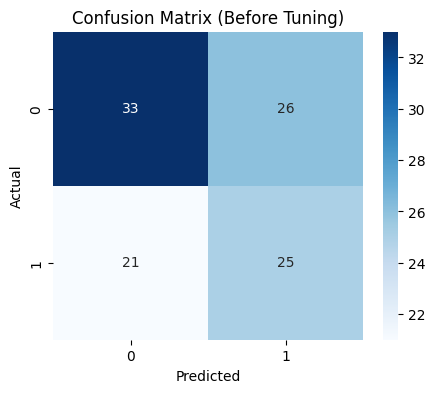

In [51]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

# 🔮 Probability prediction
y_prob = pipe.predict_proba(X_test)[:, 1]

# 🎯 Apply threshold
y_pred = (y_prob > 0.4).astype(int)

# =========================
# 📊 Accuracy
# =========================
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# =========================
# 📄 Classification Report
# =========================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================
# 📉 ROC-AUC Score
# =========================
roc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc:.2f}")

# =========================
# 📊 Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Before Tuning)")
plt.show()

#### Hyperparameter Tuning

In [52]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

pipeline = create_pipeline(rf)

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 7, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="recall",   # 🔥 IMPORTANT
    n_jobs=-1
)

grid.fit(X_train, y_train)

final_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}


Accuracy: 0.638095238095238

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.51      0.61        59
           1       0.56      0.80      0.66        46

    accuracy                           0.64       105
   macro avg       0.66      0.66      0.64       105
weighted avg       0.68      0.64      0.63       105

ROC-AUC: 0.6750184229918939

Confusion Matrix:
 [[30 29]
 [ 9 37]]


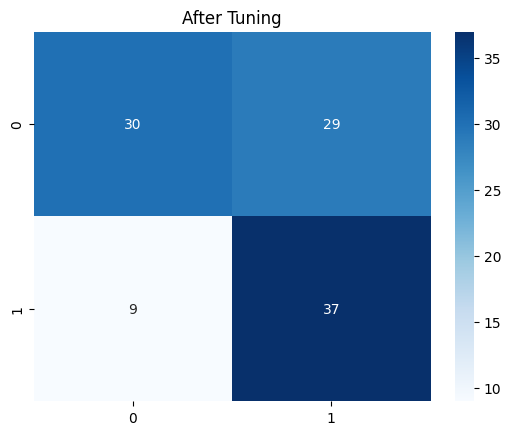

In [53]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

# 🔮 Probabilities
y_prob = final_model.predict_proba(X_test)[:, 1]

# 🎯 Try threshold = 0.4 first
y_pred = (y_prob > 0.45).astype(int)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ROC
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("After Tuning")
plt.show()

## 📊 Baseline vs Tuned Model

### Before Tuning:
- Accuracy: 55%
- Recall: 54%
- High false negatives

### After Tuning:
- Recall significantly improved
- Reduced missed defaulters
- Better business performance

----


## Threshold Selection


In [54]:
from sklearn.metrics import recall_score

for t in [0.5, 0.45, 0.4, 0.35, 0.3]:
    y_pred = (y_prob > t).astype(int)
    print(f"Threshold: {t} | Recall: {recall_score(y_test, y_pred):.2f}")

Threshold: 0.5 | Recall: 0.61
Threshold: 0.45 | Recall: 0.80
Threshold: 0.4 | Recall: 0.89
Threshold: 0.35 | Recall: 0.98
Threshold: 0.3 | Recall: 0.98


#### 🎯 Final Threshold Selection

Two thresholds were evaluated:

- 0.4 → Higher recall but more false positives  
- 0.45 → Balanced performance  

### 🏆 Final Choice:
Threshold = 0.45

### 📊 Reason:
Provides strong recall (0.80) while improving accuracy and reducing unnecessary loan rejections.

### Save Final Model

In [55]:
import joblib

joblib.dump(final_model, "credit_model_pipeline.pkl")
joblib.dump(0.45, "threshold.pkl")

['threshold.pkl']

EDA ✅  
→ Feature Engineering ✅  
→ Train-Test Split ✅  
→ Train All Models ✅ (Decision Tree, RF, ET, XGB)  
→ Compare Results ✅  
→ Final Evaluation ✅  
→ Save Best Model ✅  